In [ ]:


"""
    classification task
        - Cardboard: 461
        - Food Organics: 411
        - Glass: 420
        - Metal: 790
        - Miscellaneous Trash: 495
        - Paper: 500
        - Plastic: 921
        - Textile Trash: 318
        - Vegetation: 436


    data/RealWaste/...

    Pipeline
        - load images
        - preprocess images (resize, normalize)
        - WasteDataset(Dataset) class
        - Dataset and DataLoaders
        - model
        - training loop
        - evaluation
        
"""



In [1]:

import os

import random
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
from torch.nn.functional import softmax 
import torch.optim as optim
from torch.utils.data import Dataset, Subset, DataLoader
from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import time



In [2]:

SEED = 37

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else 
        "mps" if torch.backends.mps.is_available() else "cpu"
)

print(f"Using device {device}")


Using device mps


In [3]:

# Load Dataset

DATA_DIR = "data/RealWaste"
base_dataset = datasets.ImageFolder(root= DATA_DIR)

class_names = base_dataset.classes
#print(*class_names)
#print(base_dataset.class_to_idx)

targets = np.array(base_dataset.targets)
counts = Counter(targets)

#print("\nPer-class image counts:")
#for idx, name in enumerate(class_names):
#    print("%21s: %d" % (name, counts[idx]))
print("\nTotal Images: %d" % len(base_dataset))



Total Images: 4752


In [4]:

# Define Preprocessing

image_size = 224

IMAGENET_MEAN =  [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean= IMAGENET_MEAN, std= IMAGENET_STD)
])



In [5]:

# Stratified Training, Validation, Test Split

class TransformedSubset(Dataset):
    """
        wraps a subset of an ImageFolder,
        each split can use its own transform
    """
    
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        if self.transform is not None:
            image = self.transform(image)
        return image, label

indices = np.arange(len(base_dataset))

# startify, same proportion as the whole dataset

# dataset => 0.7 train and 0.3 temp
train_idx, temp_idx, train_labels, temp_labels = train_test_split(
    indices, targets, test_size= 0.3, stratify= targets, random_state= SEED
)

# 0.3 temp => 0.15 val and 0.15 test
val_idx, test_idx = train_test_split(
    temp_idx, test_size= 0.50, stratify= temp_labels, random_state= SEED
)

print(f"Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}")

train_dataset = TransformedSubset(Subset(base_dataset, train_idx), train_transform)
val_dataset = TransformedSubset(Subset(base_dataset, val_idx), eval_transforms)
test_dataset = TransformedSubset(Subset(base_dataset, test_idx), eval_transforms)



Train: 3326 | Val: 713 | Test: 713


In [6]:

# Build DataLoader
BATCH_SIZE = 32
NUM_WORKERS = 0
PIN_MEMORY = False

train_loader = DataLoader(
    train_dataset, 
    batch_size= BATCH_SIZE, 
    shuffle= True, 
    num_workers= NUM_WORKERS,
    pin_memory= PIN_MEMORY
)

val_loader = DataLoader(
    val_dataset, 
    batch_size= BATCH_SIZE,
    shuffle= False,
    num_workers= NUM_WORKERS,
    pin_memory= PIN_MEMORY
)

test_loader = DataLoader(
    test_dataset, 
    batch_size= BATCH_SIZE,
    shuffle= False,
    num_workers= NUM_WORKERS,
    pin_memory= PIN_MEMORY
)



In [7]:


# STEP 6. Model

# class WasteCNN(nn.Module):
#     def __init__(self, num_classes):
#         super().__init__()
#         self.features = nn.Sequential(
#             # Block 1: 256x256 -> 128x128
#             nn.Conv2d(3, 32, kernel_size= 3, padding= 1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
            
#             nn.Conv2d(32, 32, kernel_size=3, padding=1),
#             nn.BatchNorm2d(32),
#             nn.ReLU(inplace=True),
            
#             nn.MaxPool2d(2),
#             # ***
            
#             # Block 2: 128x128 -> 64x64
#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(64, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(2),

#             # Block 3: 64x64 -> 32x32
#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),
#             nn.Conv2d(128, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(2),

#             # Block 4: 32x32 -> 16x16
#             nn.Conv2d(128, 256, kernel_size=3, padding=1),
#             nn.BatchNorm2d(256),
#             nn.ReLU(inplace=True),
#             nn.MaxPool2d(2),
#         )
        
#         self.classifier = nn.Sequential(
#             nn.AdaptiveAvgPool2d((1, 1)),
#             nn.Flatten(),
#             nn.Dropout(0.4),
#             nn.Linear(256, 128),
#             nn.ReLU(inplace=True),
#             nn.Dropout(0.3),
#             nn.Linear(128, num_classes),
#         )

#     def forward(self, x):
#         x = self.features(x)
#         x = self.classifier(x)
#         return x

# model = WasteCNN(num_classes=len(class_names)).to(device)
# print(model)

# Transfer Learning 
def build_resnet18_model(num_classes, freeze_backbone= True):
    backbone = models.resnet18(weights= models.ResNet18_Weights.IMAGENET1K_V1)
    if freeze_backbone:
        for param in backbone.parameters():
            param.requires_grad = False
        
        # unfreeze last 2 blocks
        for param in backbone.layer3.parameters():
            param.requires_grad = True

        for param in backbone.layer4.parameters():
            param.requires_grad = True
    
    backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)
    return backbone

model = build_resnet18_model(num_classes= len(class_names), freeze_backbone= True).to(device)
print(model)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [8]:

# Loss function, Optimizer, Scheduler

# find each classes inverse ratio
class_counts = np.array([counts[i] for i in range(len(class_names))])
class_weights = (class_counts.sum() / len(class_names)) * (1.0 / class_counts)

class_weights_tensor = torch.tensor(class_weights, dtype= torch.float32).to(device)

print("Class weights:")
for name, w in zip(class_names, class_weights):
    print(f"  {name:22s}: {w:.3f}")

criterion = nn.CrossEntropyLoss(weight= class_weights_tensor)
optimizer = optim.Adam(
    [
        {
            "params": model.layer4.parameters(), "lr": 1e-4
        },
        {
            "params": model.fc.parameters(),     "lr": 1e-3
        },
    ],
    weight_decay= 1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode= "min", factor= 0.5, patience= 3)

# "best_waste_cnn.pt"
CHECKPOINT_PATH = "res_left_over.pt"



Class weights:
  Cardboard             : 1.145
  Food Organics         : 1.285
  Glass                 : 1.257
  Metal                 : 0.668
  Miscellaneous Trash   : 1.067
  Paper                 : 1.056
  Plastic               : 0.573
  Textile Trash         : 1.660
  Vegetation            : 1.211


In [9]:


# Training Loop

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim= 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim= 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


NUM_EPOCHS = 30
PATIENCE = 7

best_val_loss = float("inf")
epochs_no_improve = 0
history = {
    "train_loss": [], 
    "train_acc": [], 
    "val_loss": [], 
    "val_acc": []
}

for epoch in range(NUM_EPOCHS):
    start_time = time.perf_counter()
    
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)

    end_time = time.perf_counter()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    
    execution_time = end_time - start_time

    print(f"Epoch {(epoch + 1):02d}/{NUM_EPOCHS} (Execution Time: {execution_time:.6f} seconds)" +
          f"\n  train_loss : {train_loss:.4f}" +
          f"\n  train_acc  : {train_acc:.4f}" +
          f"\n  val_loss   : {val_loss:.4f}" + 
          f"\n  val_acc    : {val_acc:.4f} \n")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), CHECKPOINT_PATH)
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping triggered at epoch {epoch + 1}")
            break



Epoch 01/30 (Execution Time: 16.082940 seconds)
  train_loss : 0.8441
  train_acc  : 0.7023
  val_loss   : 0.4554
  val_acc    : 0.8247 

Epoch 02/30 (Execution Time: 15.965553 seconds)
  train_loss : 0.2127
  train_acc  : 0.9366
  val_loss   : 0.3514
  val_acc    : 0.8654 

Epoch 03/30 (Execution Time: 16.028370 seconds)
  train_loss : 0.0568
  train_acc  : 0.9901
  val_loss   : 0.3116
  val_acc    : 0.8864 

Epoch 04/30 (Execution Time: 16.217842 seconds)
  train_loss : 0.0218
  train_acc  : 0.9979
  val_loss   : 0.3140
  val_acc    : 0.8920 

Epoch 05/30 (Execution Time: 15.745479 seconds)
  train_loss : 0.0107
  train_acc  : 0.9994
  val_loss   : 0.3087
  val_acc    : 0.8892 

Epoch 06/30 (Execution Time: 15.065894 seconds)
  train_loss : 0.0060
  train_acc  : 1.0000
  val_loss   : 0.3169
  val_acc    : 0.8906 

Epoch 07/30 (Execution Time: 15.425781 seconds)
  train_loss : 0.0043
  train_acc  : 0.9997
  val_loss   : 0.3436
  val_acc    : 0.8780 

Epoch 08/30 (Execution Time: 15.51

In [10]:
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location= device))

<All keys matched successfully>

In [11]:

# Evaluate on the test set
model.eval()

all_preds, all_labels = [], []
t0 = time.perf_counter()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim= 1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

elapsed = time.perf_counter() - t0

test_accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average= "macro")

print(f"(Execution Time:  {elapsed:.4f} seconds)\n")
print(f"Test accuracy:    {test_accuracy:.4f}")
print(f"Macro precision:  {precision:.4f}")
print(f"Macro recall:     {recall:.4f}")
print(f"Macro F1:         {f1:.4f}")
print("\nFor each class:\n")
print(classification_report(all_labels, all_preds, target_names= class_names))



(Execution Time:  2.2576 seconds)

Test accuracy:    0.9046
Macro precision:  0.9022
Macro recall:     0.9109
Macro F1:         0.9055

For each class:

                     precision    recall  f1-score   support

          Cardboard       0.92      0.87      0.90        69
      Food Organics       0.90      0.97      0.93        62
              Glass       0.95      0.94      0.94        63
              Metal       0.90      0.91      0.90       118
Miscellaneous Trash       0.88      0.81      0.85        74
              Paper       0.91      0.97      0.94        75
            Plastic       0.92      0.86      0.89       138
      Textile Trash       0.80      0.92      0.85        48
         Vegetation       0.94      0.95      0.95        66

           accuracy                           0.90       713
          macro avg       0.90      0.91      0.91       713
       weighted avg       0.91      0.90      0.90       713



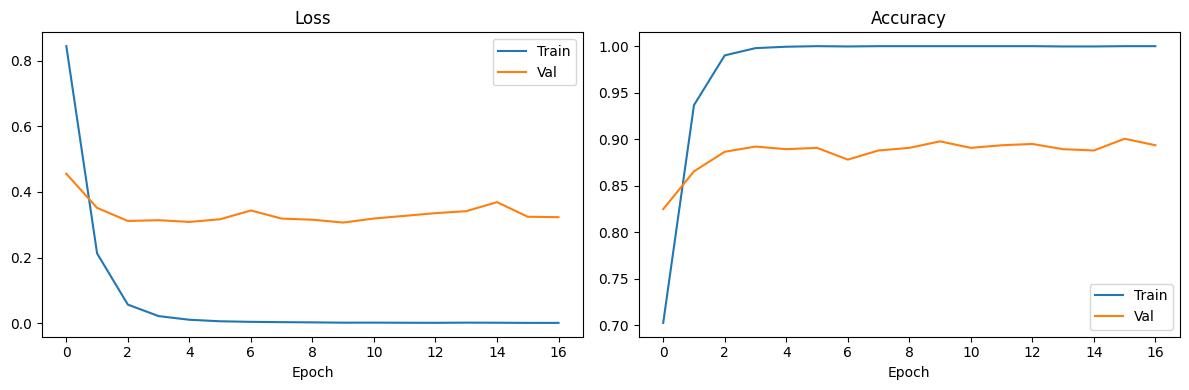

In [12]:


# Visualization
fig, axes = plt.subplots(1, 2, figsize= (12, 4))

axes[0].plot(history["train_loss"], label= "Train")
axes[0].plot(history["val_loss"], label= "Val")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(history["train_acc"], label= "Train")
axes[1].plot(history["val_acc"], label= "Val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()


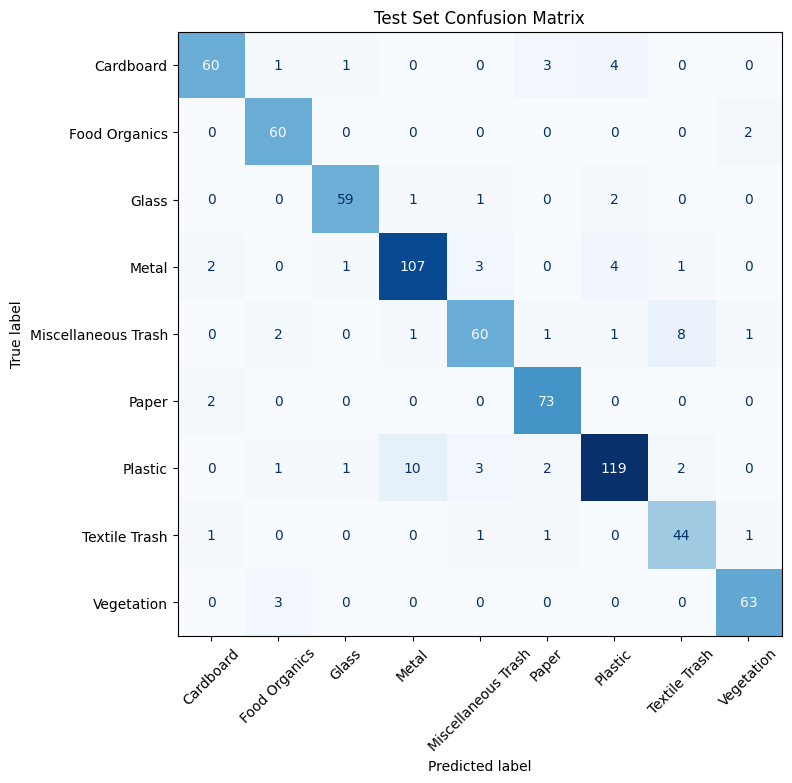

In [14]:


cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize= (8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix= cm, display_labels= class_names)
disp.plot(ax= ax, xticks_rotation= 45, cmap= "Blues", colorbar= False)
plt.title("Test Set Confusion Matrix")
plt.tight_layout()
plt.show()



In [15]:

print("Traning size    : %6d batches" % (len(train_loader)))
print("Validation size : %6d batches" % (len(val_loader)))
print("Test size       : %6d batches" % (len(test_loader)))


Traning size    :    104 batches
Validation size :     23 batches
Test size       :     23 batches


Execution Time: 0.007994 seconds 

Cardboard: 0.0000
Food Organics: 0.0000
Glass: 0.0000
Metal: 0.0000
Miscellaneous Trash: 0.9994
Paper: 0.0001
Plastic: 0.0000
Textile Trash: 0.0005
Vegetation: 0.0000


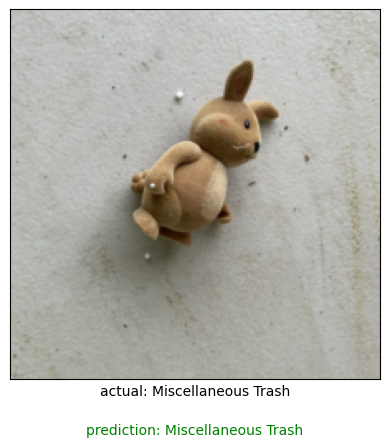

In [38]:

# ... a random image from test_dataset
start_timer = 0.0; end_timer = 0.0; execution_time = 0.0

n_samples = len(test_loader.dataset)
sample_idx = random.randrange(n_samples) # 0 to n_samples - 1

s_image, s_label = test_loader.dataset[sample_idx]
s_image = s_image.unsqueeze(0).to(device) # [channel_size, image_size, image_size] => [(batch_size) 1, 3, 256, 256]


model.eval()
with torch.no_grad():
    start_timer = time.perf_counter()
    output = model(s_image) # output.shape = [1, 9]
    end_timer = time.perf_counter()
    
    pred = output.argmax(dim= 1).item()

execution_time = end_timer - start_timer
print("Execution Time: %.6f seconds \n" % execution_time)

probs = softmax(output, dim= 1)
probs_np = probs.squeeze(0).cpu().numpy()

for idx, confidence in enumerate(probs_np):
    print(f"{class_names[idx]}: {confidence:.4f}")
    

mean = np.array(IMAGENET_MEAN)
std = np.array(IMAGENET_STD)
img = s_image.squeeze(0).permute(1, 2, 0).cpu().numpy() # shape => [image_size, image_size, channel_size]
img = std * img + mean
img = np.clip(img, 0, 1)

plt.imshow(img)
plt.xticks([])
plt.yticks([])
plt.xlabel(f"actual: {class_names[s_label]}")
plt.gca().text(
    0.5, 
    -0.12,
    f"prediction: {class_names[pred]}",
    color= "green" if (pred == s_label) else "red",
    ha= "center",
    va= "top",
    transform= plt.gca().transAxes,
)

plt.show()

